# Análise do programa Bicicletar de 2014 a 2025
Recentemente, o programa Bicicletar atingiu a marca de 9 milhões de viagens realizadas, dessa forma, o objetivo deste projeto é analisar os dados
disponibilizados pela Autarquia Municipal de Trânsito e Cidadania (AMC).
 A análise será feita utilizando a linguagem Python e a biblioteca Pandas para manipulação e análise dos dados.

### Carregar os pacotes necessários
- #### pandas = Análise de Dados
- #### plotly.express = Criação de gráficos


In [1]:
import pandas as pd
import plotly.express as px 

### Carregar os dados

In [14]:
dados2014 = pd.read_csv("Dados/dadosabertos_viagensbicicletar_2014.csv")
dados2015 = pd.read_csv("Dados/dadosabertos_viagensbicicletar_2015.csv")
dados2016 = pd.read_csv("Dados/dadosabertos_viagensbicicletar_2016.csv")
dados2017 = pd.read_csv("Dados/dadosabertos_viagensbicicletar_2017.csv")
dados2018 = pd.read_csv("Dados/dadosabertos_viagensbicicletar_2018.csv")
dados2019 = pd.read_csv("Dados/dadosabertos_viagensbicicletar_2019.csv")
dados2021 = pd.read_csv("Dados/dadosabertos_viagensbicicletar_2021.csv")
dados2022 = pd.read_csv("Dados/dadosabertos_viagensbicicletar_2022.csv", dtype={'Sexo': str})
dados2023 = pd.read_csv("Dados/dadosabertos_viagensbicicletar_2023.csv")
dados2024 = pd.read_csv("Dados/dadosabertos_viagensbicicletar_2024.csv")
dados2025 = pd.read_csv("Dados/dadosabertos_viagensbicicletar_2025.csv")

### Juntar os dados de todos os anos

In [3]:
dados_total = pd.concat([dados2014,dados2015,dados2016,dados2017,dados2018,dados2019,dados2021,dados2022,dados2023,dados2024,dados2025], ignore_index=True)
display(dados_total.info())

<class 'pandas.DataFrame'>
RangeIndex: 7547072 entries, 0 to 7547071
Data columns (total 12 columns):
 #   Column            Dtype
---  ------            -----
 0   MeioRetirada      str  
 1   IdUsuario         int64
 2   Sexo              str  
 3   DataViagem        str  
 4   HoraRetirada      str  
 5   EstacaoRetirada   int64
 6   HoraDevolucao     str  
 7   EstacaoDevolucao  int64
 8   DuracaoViagem     int64
 9   TipoEstacao       str  
 10  TipoBicicleta     str  
 11  AnoViagem         int64
dtypes: int64(5), str(7)
memory usage: 1.0 GB


None

### Corrigir o tipo de dado de algumas colunas

In [9]:

dados_total['AnoViagem'] = dados_total['AnoViagem'].astype(str) # Apesar de ser uma data, é transformado em string para facilitar a análise e visualização
dados_total['DataViagem'] = pd.to_datetime(dados_total['DataViagem'], format='%Y-%m-%d')
dados_total['HoraRetirada'] = pd.to_datetime(dados_total['HoraRetirada'], format='%H:%M:%S', errors='coerce').dt.time
dados_total['HoraDevolucao'] = pd.to_datetime(dados_total['HoraDevolucao'], format='%H:%M:%S', errors='coerce').dt.time
display(dados_total.info())

<class 'pandas.DataFrame'>
RangeIndex: 7547072 entries, 0 to 7547071
Data columns (total 12 columns):
 #   Column            Dtype         
---  ------            -----         
 0   MeioRetirada      str           
 1   IdUsuario         int64         
 2   Sexo              str           
 3   DataViagem        datetime64[us]
 4   HoraRetirada      object        
 5   EstacaoRetirada   int64         
 6   HoraDevolucao     object        
 7   EstacaoDevolucao  int64         
 8   DuracaoViagem     int64         
 9   TipoEstacao       str           
 10  TipoBicicleta     str           
 11  AnoViagem         str           
dtypes: datetime64[us](1), int64(4), object(2), str(5)
memory usage: 906.8+ MB


None

### Visualizando o total de viagens por tipo de bicicleta

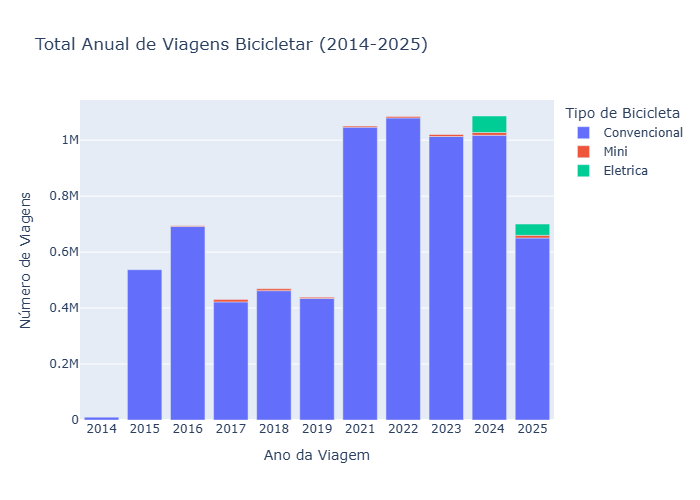

In [6]:
viagens_ano_tipo = dados_total.groupby(['AnoViagem', 'TipoBicicleta']).size().reset_index(name='Quantidade') # Agrupando antes para evitar alto consumo de memória

grafico1 =px.bar(
    viagens_ano_tipo,
    x='AnoViagem', 
    y='Quantidade',
    color='TipoBicicleta', 
    title='Total Anual de Viagens Bicicletar (2014-2025)',
    labels={'AnoViagem': 'Ano da Viagem', 'Quantidade': 'Número de Viagens', 'TipoBicicleta': 'Tipo de Bicicleta'}
)

grafico1.show(renderer="png")

#### Observações sobre a contagem de viagens:
- 2014: Apresenta um baixo volume de viagens, pois o programa foi iniciado apenas em dezembro daquele ano.
- 2025: Possui um registro substancialmente menor em relação a 2024 devido à data de corte dos dados (atualizados apenas até julho de 2025).

##### A análise do histograma também revelou a presença de viagens do tipo ``mini'' no ano de 2016. No entanto, o levantamento de notícias da época indica que a implementação dessa modalidade ocorreu apenas em 2 de julho de 2017. Diante dessa inconsistência, será realizada uma investigação detalhada desses registros para identificar a possível origem do erro.

In [12]:
erros = (dados_total['TipoBicicleta'] == 'Mini') & (dados_total['DataViagem'] < '2017-07-01') #Criar a condição
Dados_erro = dados_total[erros] # Criar um novo DataFrame com os dados que atendem a condição
Dados_erro.head(10) # Vizualizar os primeiros 10 registros do DataFrame com os dados que atendem a condição

,MeioRetirada,IdUsuario,Sexo,DataViagem,HoraRetirada,EstacaoRetirada,HoraDevolucao,EstacaoDevolucao,DuracaoViagem,TipoEstacao,TipoBicicleta,AnoViagem
650753,BU,2450600,M,2016-03-10,13:51:30,54,14:21:45,52,30,Bicicletar,Mini,2016
650868,BU,1848200,M,2016-03-10,15:22:01,52,15:30:41,50,9,Bicicletar,Mini,2016
650956,BU,1862781,F,2016-03-10,16:20:03,50,16:58:00,50,39,Bicicletar,Mini,2016
651002,BU,2438266,M,2016-03-10,16:47:27,56,17:04:23,36,42,Bicicletar,Mini,2016
651217,BU,1950023,M,2016-03-10,17:54:21,36,17:57:54,32,7,Bicicletar,Mini,2016
651250,BU,2273511,M,2016-03-10,18:03:53,32,18:21:53,40,17,Bicicletar,Mini,2016
651275,BU,2632498,M,2016-03-10,18:10:05,50,18:16:26,48,7,Bicicletar,Mini,2016
651324,APP,2347632,F,2016-03-10,18:27:17,40,18:39:15,34,49,Bicicletar,Mini,2016
651412,BU,1639753,M,2016-03-10,18:56:53,48,19:30:48,48,34,Bicicletar,Mini,2016
651459,BU,2304206,M,2016-03-10,19:16:09,34,19:21:56,36,6,Bicicletar,Mini,2016


##### 